In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load dataset
data = pd.read_csv("data/spirometry_dataset.csv")

# remove empty columns
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

print(data.head())

   Age     Sex  Height_cm  Weight_kg   BMI Smoking_Status  FEV1_L  FVC_L  \
0   47  Female      164.7       45.7  16.8         Former    5.29   7.00   
1   57    Male      171.6       74.3  25.2         Former    5.48   7.00   
2   35  Female      161.8       81.1  31.0         Former    5.00   6.83   
3   40  Female      160.1       45.0  17.6          Never    5.68   7.00   
4   68  Female      157.2       55.4  22.4        Current    2.92   6.28   

   COPD_Label  
0           0  
1           0  
2           0  
3           0  
4           1  


In [3]:
data["Sex"] = data["Sex"].replace({
    "Male": 1,
    "Female": 0
})

data["Smoking_Status"] = data["Smoking_Status"].replace({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

C:\Users\Anju\AppData\Local\Temp\ipykernel_13584\1558714068.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Sex"] = data["Sex"].replace({
C:\Users\Anju\AppData\Local\Temp\ipykernel_13584\1558714068.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Smoking_Status"] = data["Smoking_Status"].replace({


In [4]:
print(data.head())
print(data.isnull().sum())

   Age  Sex  Height_cm  Weight_kg   BMI  Smoking_Status  FEV1_L  FVC_L  \
0   47    0      164.7       45.7  16.8               1    5.29   7.00   
1   57    1      171.6       74.3  25.2               1    5.48   7.00   
2   35    0      161.8       81.1  31.0               1    5.00   6.83   
3   40    0      160.1       45.0  17.6               0    5.68   7.00   
4   68    0      157.2       55.4  22.4               2    2.92   6.28   

   COPD_Label  
0           0  
1           0  
2           0  
3           0  
4           1  
Age               0
Sex               0
Height_cm         0
Weight_kg         0
BMI               0
Smoking_Status    0
FEV1_L            0
FVC_L             0
COPD_Label        0
dtype: int64


In [5]:
X = data.drop(["COPD_Label"], axis=1)
y = data["COPD_Label"]

In [6]:
import numpy as np

data["FEV1_L"] = data["FEV1_L"] + np.random.normal(0,0.3,len(data))
data["FVC_L"] = data["FVC_L"] + np.random.normal(0,0.3,len(data))

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from tensorflow.keras.layers import Dropout
model = Sequential()

model.add(Dense(8, activation="relu", input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(4, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

c:\Users\Anju\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Train
model.fit(X_train, y_train, epochs=15, batch_size=16)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5439 - loss: 0.8962
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5973 - loss: 0.7122
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6518 - loss: 0.6084
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7560 - loss: 0.5445
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7594 - loss: 0.5228
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7878 - loss: 0.4754
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8408 - loss: 0.4069
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8711 - loss: 0.3678
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8919 - loss: 0.3226
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9354 - loss: 0.2447
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9026 - loss: 0.2454
Epoch 12/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9186 - lo

In [12]:
model.save("ann_model.h5")

In [13]:
# Test accuracy
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9695 - loss: 0.0821  
Accuracy: 0.9750000238418579


In [14]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9701 - loss: 0.0851 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9695 - loss: 0.0821 
Train Accuracy: 0.9762499928474426
Test Accuracy: 0.9750000238418579


In [15]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


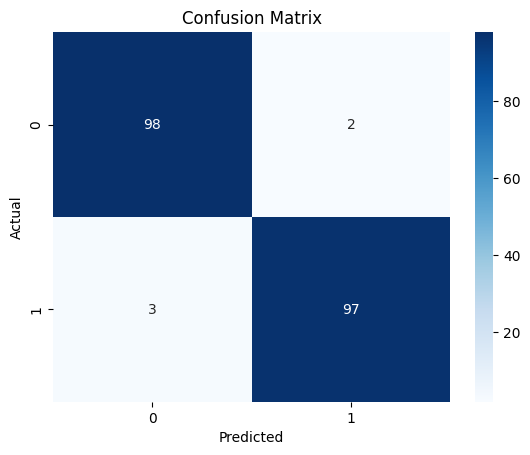

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9491 - loss: 0.1497 - val_accuracy: 0.9875 - val_loss: 0.0767
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9591 - loss: 0.1053 - val_accuracy: 0.9875 - val_loss: 0.0722
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9571 - loss: 0.1282 - val_accuracy: 0.9875 - val_loss: 0.0681
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9621 - loss: 0.1270 - val_accuracy: 0.9875 - val_loss: 0.0638
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9651 - loss: 0.1169 - val_accuracy: 0.9875 - val_loss: 0.0602
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9472 - loss: 0.1236 - val_accuracy: 0.9875 - val_loss: 0.0574
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9603 - loss: 0.1119 - val_accuracy: 0.9875 - val_loss: 0.0542
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9694 - loss: 0.0968 - val_accuracy: 0.9875 - v

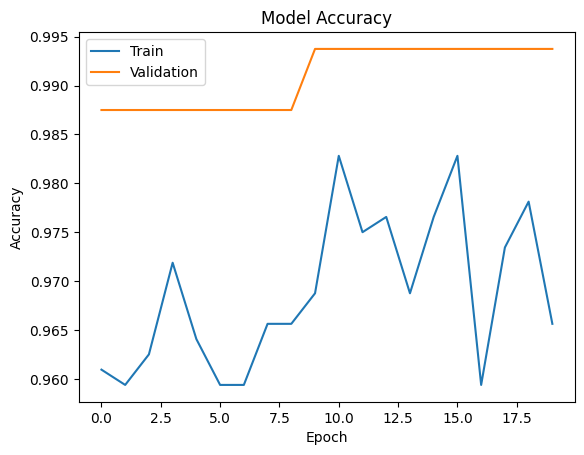

In [17]:
import matplotlib.pyplot as plt

history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

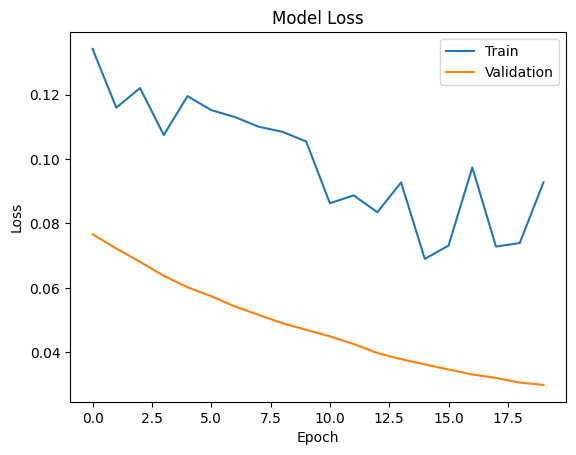

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])
plt.show()

In [19]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']